In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
!pip install qiskit
!pip install qiskit-machine-learning
!pip install pennylane
!pip install pylatexenc

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.5/6.5 MB 89.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 119.7/119.7 kB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 77.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.5/49.5 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.7/49.7 MB 20.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 109.0/109.0 kB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 231.6/231.6 kB 9.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.1/56.1 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 57.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 930.8/930.8 kB 47.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 76.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.9/167.9 kB 12.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.6/8.6 M

In [4]:
# Amplitude encoding with a large vector
import numpy as np
import pandas as pd
from qiskit import QuantumCircuit
from qiskit.circuit.library import StatePreparation

In [5]:
sample_dan_sequence = pd.read_csv(r'/content/drive/MyDrive/Academic/CSCI 300 qUANTUM cOMPUTING/Project/Dataset/sample_dna_encoded_matrix.csv')

In [6]:
sample_dan_sequence.shape

(400, 56552)

In [25]:
# libraries needed for conducting Isomap
from sklearn.manifold import Isomap
from sklearn.metrics import pairwise_distances
import pandas as pd
import numpy as np

In [58]:
# Use your high-dimensional input
X = sample_dan_sequence.values.astype(float)

# Step 1: Compute full pairwise distances in the original space
D_original = pairwise_distances(X)

# Step 2: Run Isomap to get reduced dimensions (e.g., 10 for explanation analysis)
n_components = 32
isomap = Isomap(n_neighbors=3, n_components=n_components)
X_iso = isomap.fit_transform(X)

# Step 3: Compute pairwise distances in reduced space
D_reduced = pairwise_distances(X_iso)

# Step 4: Compute how much variance is preserved
# Flatten the upper triangle (excluding diagonal)
orig_flat = D_original[np.triu_indices_from(D_original, k=1)]
reduced_flat = D_reduced[np.triu_indices_from(D_reduced, k=1)]

# Compute R^2 as an approximation of variance preserved
correlation_matrix = np.corrcoef(orig_flat, reduced_flat)
r_squared = correlation_matrix[0, 1] ** 2

print(f"Approximate variance explained by {n_components} Isomap components: {r_squared * 100:.2f}%")


Approximate variance explained by 32 Isomap components: 11.55%


In [59]:
X_reduced_df = pd.DataFrame(X_iso, columns=[f"iso_{i}" for i in range(n_components)])
X_reduced_df.head()

,iso_0,iso_1,iso_2,iso_3,iso_4,iso_5,iso_6,iso_7,iso_8,iso_9,...,iso_22,iso_23,iso_24,iso_25,iso_26,iso_27,iso_28,iso_29,iso_30,iso_31
0,-15.362982,-33.723243,-48.325984,-14.324715,0.840278,-8.386696,-5.049756,4.297928,32.253177,9.604016,...,15.344996,-17.527052,-5.529161,20.295705,-7.859760,-41.880096,-1.963845,-5.644591,-30.410879,-21.734200
1,-91.026368,-79.833426,0.126732,9.060403,56.142503,216.724994,42.609097,102.281863,-83.215810,19.215988,...,48.672000,23.195282,-15.125980,-15.520431,-30.620859,-5.714297,-3.726805,-1.333001,74.110459,-20.196314
2,-73.079626,-4.826638,-20.572967,-11.143792,-1.693887,3.721262,-7.376187,-22.025883,3.665221,-6.563661,...,2.502701,-1.507954,2.615991,2.991199,-9.855541,-0.541634,-6.650517,-0.739577,-2.748529,-0.146820
3,24.635574,69.226333,56.957079,-90.662977,224.515418,-118.664976,14.516115,57.143459,-45.891910,-134.440346,...,28.900433,-7.073657,24.405711,16.864092,-2.230246,-61.393570,37.700060,-9.440810,-7.164856,-37.182811
4,-71.040758,-4.963124,-20.344682,-9.364839,0.277923,0.807031,-3.653959,-14.794232,1.862348,-2.654579,...,31.532174,-19.663917,4.943421,15.050969,51.845089,59.398164,22.211658,0.758140,-3.956342,-23.173151


In [60]:
print(X_reduced_df.head())
first_row = X_reduced_df.iloc[0, 1:].values.astype(float)

       iso_0      iso_1      iso_2      iso_3       iso_4       iso_5  \
0 -15.362982 -33.723243 -48.325984 -14.324715    0.840278   -8.386696   
1 -91.026368 -79.833426   0.126732   9.060403   56.142503  216.724994   
2 -73.079626  -4.826638 -20.572967 -11.143792   -1.693887    3.721262   
3  24.635574  69.226333  56.957079 -90.662977  224.515418 -118.664976   
4 -71.040758  -4.963124 -20.344682  -9.364839    0.277923    0.807031   

       iso_6       iso_7      iso_8       iso_9  ...     iso_22     iso_23  \
0  -5.049756    4.297928  32.253177    9.604016  ...  15.344996 -17.527052   
1  42.609097  102.281863 -83.215810   19.215988  ...  48.672000  23.195282   
2  -7.376187  -22.025883   3.665221   -6.563661  ...   2.502701  -1.507954   
3  14.516115   57.143459 -45.891910 -134.440346  ...  28.900433  -7.073657   
4  -3.653959  -14.794232   1.862348   -2.654579  ...  31.532174 -19.663917   

      iso_24     iso_25     iso_26     iso_27     iso_28    iso_29     iso_30  \
0  -5.52916

In [61]:
def pad_to_power_of_2(data):
    """Pad data with zeros to the nearest power of 2"""
    next_power = 2 ** int(np.ceil(np.log2(len(data))))
    padded_data = np.zeros(next_power)
    padded_data[:len(data)] = data  # Retaining original values
    return padded_data

In [62]:
padded_data = pad_to_power_of_2(first_row)

In [63]:
vector = padded_data  # Using the papped first row of the dataset as the vector
qbits = list(np.arange(int(np.log2(len(vector)))))  # Number of qubits for the circuit
vector /= np.linalg.norm(vector)  # Normalize explicitly

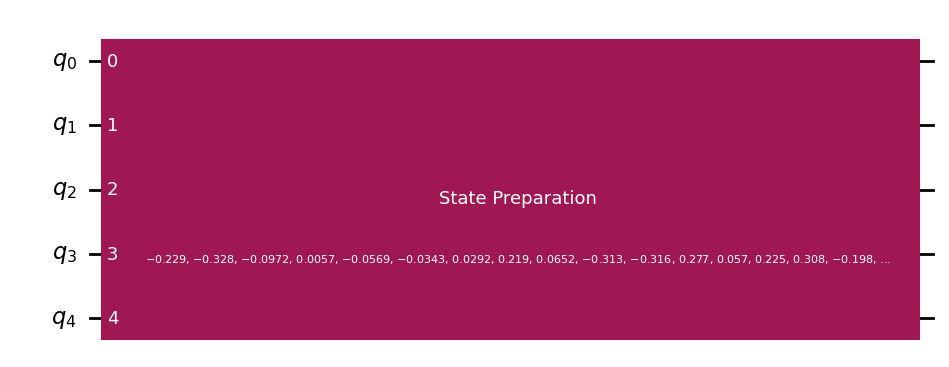

In [64]:
qc = QuantumCircuit(len(qbits))
qc.append(StatePreparation(vector), qbits)
display(qc.draw(output="mpl"))

In [ ]:
pip